# Домашнее задание к семинару 07 (HW07)

## Импорты библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
silhouette_score,
davies_bouldin_score,
calinski_harabasz_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Загрузка данных и первичный анализ

### S07-hw-dataset-01

In [7]:
df_1 = pd.read_csv("data/S07-hw-dataset-01.csv")

In [3]:
df_1.shape

(12000, 9)

In [4]:
df_1.head()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [8]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [9]:
df_1.describe()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [10]:
print("Количество пропусков:\n")
print(df_1.isna().sum())

print("\nДоля пропусков:\n")
print(df_1.isna().sum() / len(df_1))

Количество пропусков:

sample_id    0
f01          0
f02          0
f03          0
f04          0
f05          0
f06          0
f07          0
f08          0
dtype: int64

Доля пропусков:

sample_id    0.0
f01          0.0
f02          0.0
f03          0.0
f04          0.0
f05          0.0
f06          0.0
f07          0.0
f08          0.0
dtype: float64


In [11]:
df_1.dtypes

sample_id      int64
f01          float64
f02          float64
f03          float64
f04          float64
f05          float64
f06          float64
f07          float64
f08          float64
dtype: object

In [12]:
for col in df_1.columns[1:]:
    if len(df_1[col].unique()) < 20:
        print(f"{col} - категориальный признак")
    else:
        print(f"{col} - числовой признак")

f01 - числовой признак
f02 - числовой признак
f03 - числовой признак
f04 - числовой признак
f05 - числовой признак
f06 - числовой признак
f07 - числовой признак
f08 - числовой признак


In [13]:
X_1 = df_1.iloc()[:, 1:]
sample_id_1 = df_1.iloc[:, 0]

### S07-hw-dataset-02

In [14]:
df_2 = pd.read_csv("data/S07-hw-dataset-02.csv")

In [15]:
df_2.shape

(8000, 4)

In [16]:
df_2.head()

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [17]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


In [18]:
df_2.describe()

,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [19]:
print("Количество пропусков:\n")
print(df_2.isna().sum())

print("\nДоля пропусков:\n")
print(df_2.isna().sum() / len(df_2))

Количество пропусков:

sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64

Доля пропусков:

sample_id    0.0
x1           0.0
x2           0.0
z_noise      0.0
dtype: float64


In [20]:
df_2.dtypes

sample_id      int64
x1           float64
x2           float64
z_noise      float64
dtype: object

In [21]:
for col in df_2.columns[1:]:
    if len(df_2[col].unique()) < 20:
        print(f"{col} - категориальный признак")
    else:
        print(f"{col} - числовой признак")

x1 - числовой признак
x2 - числовой признак
z_noise - числовой признак


In [22]:
X_2 = df_2.iloc()[:, 1:]
sample_id_2 = df_2.iloc[:, 0]

### S07-hw-dataset-03

In [23]:
df_3 = pd.read_csv("data/S07-hw-dataset-03.csv")

In [24]:
df_3.shape

(15000, 5)

In [25]:
df_3.head()

,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


In [26]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


In [27]:
df_3.describe()

,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


In [28]:
print("Количество пропусков:\n")
print(df_3.isna().sum())

print("\nДоля пропусков:\n")
print(df_3.isna().sum() / len(df_3))

Количество пропусков:

sample_id    0
x1           0
x2           0
f_corr       0
f_noise      0
dtype: int64

Доля пропусков:

sample_id    0.0
x1           0.0
x2           0.0
f_corr       0.0
f_noise      0.0
dtype: float64


In [29]:
df_3.dtypes

sample_id      int64
x1           float64
x2           float64
f_corr       float64
f_noise      float64
dtype: object

In [30]:
for col in df_3.columns[1:]:
    if len(df_3[col].unique()) < 20:
        print(f"{col} - категориальный признак")
    else:
        print(f"{col} - числовой признак")

x1 - числовой признак
x2 - числовой признак
f_corr - числовой признак
f_noise - числовой признак


In [31]:
X_3 = df_3.iloc()[:, 1:]
sample_id_3 = df_3.iloc[:, 0]

### S07-hw-dataset-04

In [32]:
df_4 = pd.read_csv("data/S07-hw-dataset-04.csv")

In [33]:
df_4.shape

(10000, 33)

In [34]:
df_4.head()

,sample_id,cat_a,cat_b,n01,n02,n03,n04,n05,n06,n07,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
0,0,B,X,-4.827501,-24.507466,-7.852963,0.771781,28.297884,-4.493911,-42.769449,...,24.597176,-26.354320,4.543397,-19.549036,-3.051332,-5.538587,-3.084457,5.499629,-6.128896,3.132067
1,1,F,V,51.302500,NaN,5.534737,51.305464,-8.027553,28.297548,NaN,...,-18.216260,8.527932,17.202115,-30.452260,0.855326,1.199066,3.597555,-2.239703,2.932710,0.473145
2,2,A,W,-4.820828,-2.625385,27.891578,1.523041,-5.776687,-16.298523,2.462937,...,-48.260775,9.313232,12.323411,55.081325,-3.945606,-0.280540,-0.130583,-7.353205,-2.942836,1.460477
3,3,B,X,-2.627573,-25.063639,-9.450011,-8.344669,22.371118,-11.525848,-43.762607,...,24.700663,-25.466915,-3.398665,-18.174541,0.438229,3.152556,3.859283,-2.678769,-2.213923,-4.724639
4,4,C,Y,-11.415710,-8.692169,48.636163,14.661826,-39.634618,10.769075,40.187536,...,-79.710383,-13.694253,41.575892,-9.498640,1.529608,-1.641347,3.500090,3.111257,1.475232,-1.321676


In [35]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  10000 non-null  int64  
 1   cat_a      10000 non-null  object 
 2   cat_b      10000 non-null  object 
 3   n01        9826 non-null   float64
 4   n02        9811 non-null   float64
 5   n03        9801 non-null   float64
 6   n04        9808 non-null   float64
 7   n05        9799 non-null   float64
 8   n06        9817 non-null   float64
 9   n07        9796 non-null   float64
 10  n08        9806 non-null   float64
 11  n09        9805 non-null   float64
 12  n10        9811 non-null   float64
 13  n11        9796 non-null   float64
 14  n12        9798 non-null   float64
 15  n13        9803 non-null   float64
 16  n14        9802 non-null   float64
 17  n15        9814 non-null   float64
 18  n16        9809 non-null   float64
 19  n17        9788 non-null   float64
 20  n18    

In [36]:
df_4.describe()

,sample_id,n01,n02,n03,n04,n05,n06,n07,n08,n09,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
count,10000.00000,9826.000000,9811.000000,9801.000000,9808.000000,9799.000000,9817.000000,9796.000000,9806.000000,9805.000000,...,9785.000000,9804.000000,9829.000000,9793.000000,9815.000000,9776.000000,9803.000000,9789.000000,9798.000000,9805.000000
mean,4999.50000,17.348435,-2.057620,7.908302,14.269157,0.900590,5.832787,-0.840875,-4.888128,3.184200,...,-12.716502,-0.506241,8.360226,0.026943,0.039297,-0.037155,0.028512,-0.030738,-0.018685,-0.030254
std,2886.89568,22.578551,19.043410,25.637807,18.815319,20.981294,13.221646,26.583849,15.466271,32.208740,...,37.290305,14.336833,17.754646,26.121335,3.009995,3.020813,3.028106,3.000090,3.014209,3.014573
min,0.00000,-22.437090,-37.546998,-38.136412,-23.374316,-45.914070,-20.650038,-60.297304,-44.464550,-70.904880,...,-89.640783,-35.102360,-25.014050,-49.423300,-11.225848,-14.446922,-10.840777,-11.679259,-11.437909,-11.491223
25%,2499.75000,-3.975438,-14.200552,-8.591513,-1.223379,-5.086756,-4.532057,-13.554720,-17.352641,-11.460490,...,-41.284671,-11.563652,-2.123576,-19.425213,-1.973213,-2.082235,-2.007628,-2.074500,-2.051778,-2.074396
50%,4999.50000,22.042807,-6.532183,0.350400,10.069142,2.413111,7.391953,-2.429024,-7.095546,13.258691,...,-1.145681,2.491416,6.691365,-8.464171,0.037806,-0.033336,0.031588,-0.043127,-0.015441,-0.015903
75%,7499.25000,37.535647,2.092197,30.725630,29.807101,18.398883,13.033076,16.095731,3.909111,20.188426,...,18.916379,11.903004,14.939690,16.861978,2.048648,2.019027,2.056870,1.980217,2.013964,2.031215
max,9999.00000,65.446912,43.326647,60.185729,65.094588,42.527554,39.933274,48.591236,31.335431,64.696045,...,49.157087,22.452135,46.892903,61.540902,11.002135,11.394631,11.936846,10.663960,10.665988,13.755203


In [37]:
print("Количество пропусков:\n")
print(df_4.isna().sum())

print("\nДоля пропусков:\n")
print(df_4.isna().sum() / len(df_4))

Количество пропусков:

sample_id      0
cat_a          0
cat_b          0
n01          174
n02          189
n03          199
n04          192
n05          201
n06          183
n07          204
n08          194
n09          195
n10          189
n11          204
n12          202
n13          197
n14          198
n15          186
n16          191
n17          212
n18          212
n19          187
n20          203
n21          215
n22          196
n23          171
n24          207
n25          185
n26          224
n27          197
n28          211
n29          202
n30          195
dtype: int64

Доля пропусков:

sample_id    0.0000
cat_a        0.0000
cat_b        0.0000
n01          0.0174
n02          0.0189
n03          0.0199
n04          0.0192
n05          0.0201
n06          0.0183
n07          0.0204
n08          0.0194
n09          0.0195
n10          0.0189
n11          0.0204
n12          0.0202
n13          0.0197
n14          0.0198
n15          0.0186
n16          0.0191
n17  

In [38]:
df_4.dtypes

sample_id      int64
cat_a         object
cat_b         object
n01          float64
n02          float64
n03          float64
n04          float64
n05          float64
n06          float64
n07          float64
n08          float64
n09          float64
n10          float64
n11          float64
n12          float64
n13          float64
n14          float64
n15          float64
n16          float64
n17          float64
n18          float64
n19          float64
n20          float64
n21          float64
n22          float64
n23          float64
n24          float64
n25          float64
n26          float64
n27          float64
n28          float64
n29          float64
n30          float64
dtype: object

In [39]:
for col in df_4.columns[1:]:
    if len(df_4[col].unique()) < 20:
        print(f"{col} - категориальный признак")
    else:
        print(f"{col} - числовой признак")

cat_a - категориальный признак
cat_b - категориальный признак
n01 - числовой признак
n02 - числовой признак
n03 - числовой признак
n04 - числовой признак
n05 - числовой признак
n06 - числовой признак
n07 - числовой признак
n08 - числовой признак
n09 - числовой признак
n10 - числовой признак
n11 - числовой признак
n12 - числовой признак
n13 - числовой признак
n14 - числовой признак
n15 - числовой признак
n16 - числовой признак
n17 - числовой признак
n18 - числовой признак
n19 - числовой признак
n20 - числовой признак
n21 - числовой признак
n22 - числовой признак
n23 - числовой признак
n24 - числовой признак
n25 - числовой признак
n26 - числовой признак
n27 - числовой признак
n28 - числовой признак
n29 - числовой признак
n30 - числовой признак


In [40]:
X_4 = df_4.iloc()[:, 1:]
sample_id_4 = df_4.iloc[:, 0]

## Препроцессинг 

In [41]:
scaler = StandardScaler()

X_1_scaler = scaler.fit_transform(X_1)

X_2_scaler = scaler.fit_transform(X_2)

X_3_scaler = scaler.fit_transform(X_3)

In [42]:
X_4 = X_4.iloc[:, 2:]

imputer_median = SimpleImputer(strategy="median")
X_4_full = pd.DataFrame(imputer_median.fit_transform(X_4), columns=X_4.columns)
X_4_scaler = scaler.fit_transform(X_4_full)

## Модели недели 7 

In [43]:
def save_metrics(X, labels):
    unique = np.unique(labels)
    if len(unique) < 2:
        return None
    if len(unique) == 1:
        return 1
    try:
        sil = float(silhouette_score(X, labels))
    except Exeption:
        sil = None
    try:
        db = float(davies_boundlin_csore(X, labels))
    except Exception:
        db = None
    try: 
        ch = float(calinski_harabasz_score(X, labels))
    except Exception:
        ch = None
    return {"silhouette": sil, "davies_boundlin": db, "calinski_harabasz": ch}
    

In [44]:
kmeans_ks = list(range(2, 25))

In [45]:
def eval_kmeans_grid(X_feat, ks):
    results = []
    for k in ks:
        try: 
            model = KMeans(n_clusters=k, random_state = RANDOM_STATE, n_init="auto")
        except TypeError: 
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X_feat)
        metrics = save_metrics(X_feat, labels)
        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clasters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

In [153]:
min_samples = [3, 5, 10, 8, 15]
eps = [0.5, 1, 1.5, 2, 2.5, 3, 3.5,]

In [76]:
def eval_dbscan_grid(X_feat, eps_list, min_samples_list):
    results = []
    n = len(X_feat)

    for eps in eps_list:
        for ms in min_samples_list:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_feat)

            noise_frac = float(np.mean(labels == -1))
            mask = labels != -1
            labels_nn = labels[mask]
            X_nn = X_feat[mask]

            if len(labels_nn) > 0:
                uniq = np.unique(labels_nn)
                mapping = {u: i for i, u in enumerate(uniq)}
                labels_nn = np.array([mapping[v] for v in labels_nn], dtype=int)

            metrics = None
            n_clusters = 0
            if len(X_nn) >= 10 and len(np.unique(labels_nn)) >= 2:
                metrics = save_metrics(X_nn, labels_nn)
                n_clusters = len(np.unique(labels_nn))

            results.append({
                "algo": "dbscan",
                "params": {"eps": float(eps), "min_samples": int(ms)},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": int(n_clusters),
                "noise_frac": float(noise_frac),
                "n_non_noise": int(mask.sum()),
            })
    return results

In [120]:
def pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE):
    p = PCA(n_components=2, random_state=random_state)
    return p.fit_transform(X_scaled)

In [121]:
def plot_2d_embedding(emb2d, labels, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, s=18)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.grid(True, alpha=0.2)
    plt.show()

In [87]:
agg_ks = list(range(2, 25))
agg_linkage = ["ward", "complete", "average", "single"]

In [100]:
def eval_agglomerative_grid(X_feat, ks, linkages):
    results = []
    for linkage_name in linkages:
        for k in ks:
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
                labels = model.fit_predict(X_feat)
            except Exception:
                continue

            metrics = save_metrics(X_feat, labels)

            results.append({
                "algo": "agglomerative",
                "params": {"k": int(k), "linkage": linkage_name},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": len(np.unique(labels)),
                "noise_frac": 0.0,
            })
    return results

In [106]:
def print_result_card(name, result):
    m = result["metrics"] or {}
    print("=" * 72)
    print(f"{name}")
    print("algo:", result["algo"])
    print("params:", result["params"])
    print("n_clusters:", result.get("n_clusters"))
    if result["algo"] == "dbscan":
        print("noise_frac:", round(result.get("noise_frac", 0.0), 3), " non-noise:", result.get("n_non_noise"))
    print("metrics:")
    print("  silhouette:", None if m.get("silhouette") is None else round(m["silhouette"], 3))
    print("  davies_bouldin:", None if m.get("davies_bouldin") is None else round(m["davies_bouldin"], 3))
    print("  calinski_harabasz:", None if m.get("calinski_harabasz") is None else round(m["calinski_harabasz"], 1))
    if result.get("inertia") is not None:
        print("  inertia:", round(result["inertia"], 1))



In [108]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

## Датасет 1

### kmeans

In [46]:
k_means_results_1 = eval_kmeans_grid(X_1_scaler, kmeans_ks)

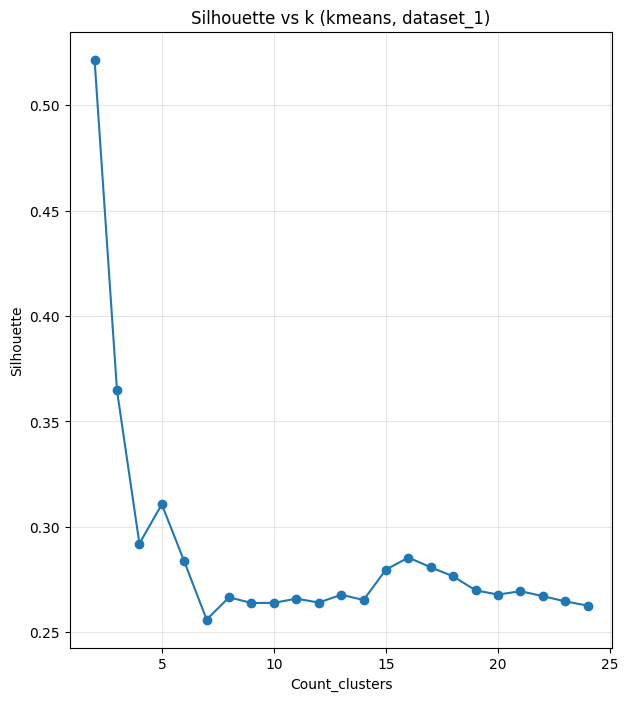

In [166]:
ks_1 = [r["params"]["k"] for r in k_means_results_1]
sil_1 = [r["metrics"]["silhouette"] for r in k_means_results_1]

plt.figure(figsize=(7,8))
plt.plot(ks_1, sil_1, marker="o")
plt.title("Silhouette vs k (kmeans, dataset_1)")
plt.xlabel("Count_clusters")
plt.ylabel("Silhouette")
plt.grid(alpha=0.3)
plt.savefig("artifacts/figures/Silhouette vs k (kmeans, dataset_1)")
plt.show()

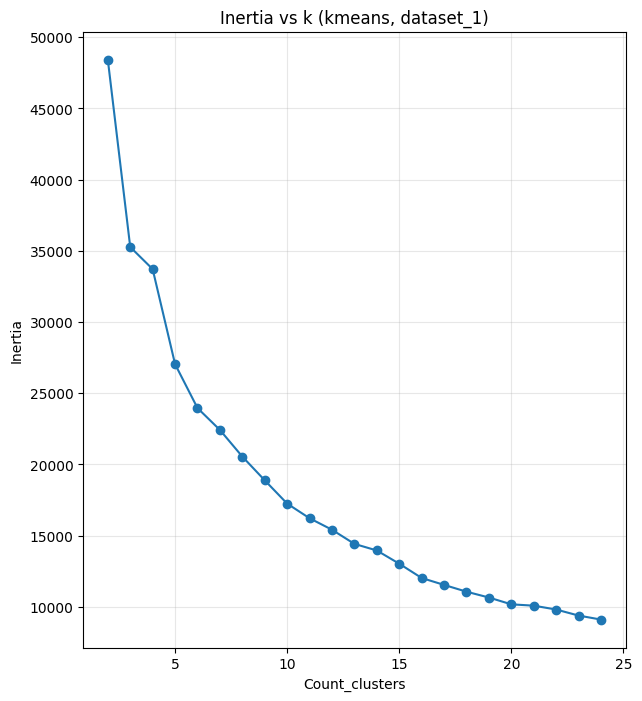

In [167]:
inertia_1 = [r["inertia"] for r in k_means_results_1]
plt.figure(figsize=(7,8))
plt.plot(ks_1, inertia_1, marker="o")
plt.title("Inertia vs k (kmeans, dataset_1)")
plt.xlabel("Count_clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.savefig("artifacts/figures/Inertia vs k (kmeans, dataset_1)")
plt.show()

In [143]:
best_kmeans_1, best_kmeans_s_1 = pick_best_by_silhouette(k_means_results_1)
best_kmeans_1

{'algo': 'kmeans',
 'params': {'k': 2},
 'labels': array([1, 0, 0, ..., 1, 0, 1], shape=(12000,), dtype=int32),
 'metrics': {'silhouette': 0.5216395622404242,
  'davies_boundlin': None,
  'calinski_harabasz': 11786.95462267153},
 'inertia': 48425.906976593935,
 'n_clasters': 2,
 'noise_frac': 0.0}

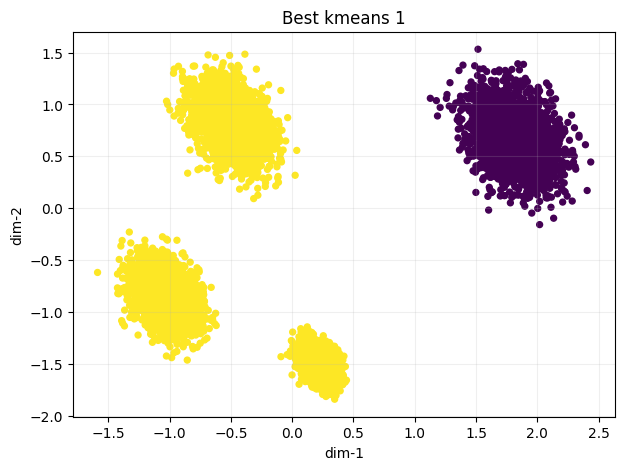

In [126]:
plot_2d_embedding(X_1_scaler, best_kmeans_1["labels"], "Best kmeans 1")

### DBSCAN

In [77]:
dbscan_results_1 = eval_dbscan_grid(X_1_scaler, eps, min_samples)

In [84]:
valid = [r for r in dbscan_results_1 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid))

valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid DBSCAN configs: 20
{'eps': 2.0, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 10} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 8} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 15} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 10} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 8} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 15} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 1.5, 'min_samples': 3} sil= 0.397 noise= 0.0 clusters= 3
{'eps': 1.5, 'min_samples': 5} sil= 0.397 noise= 0.0 clusters= 3
{'eps': 1.5, 'min_samples': 10} sil= 0.397 noise= 0.0 clusters= 3
{'eps': 1.5, 'min_samples': 8} sil= 0.397 noise= 0.0 clusters= 3
{'eps': 1.5, 'min_samples': 15} sil= 0.397 noise= 0.0 cluste

In [164]:
best_dbscan_1, best_dbscan_s_1 = pick_best_by_silhouette(dbscan_results_1)
best_dbscan_1

{'algo': 'dbscan',
 'params': {'eps': 2.0, 'min_samples': 3},
 'labels': array([0, 1, 1, ..., 0, 1, 0], shape=(12000,)),
 'metrics': {'silhouette': 0.5216395622404242,
  'davies_boundlin': None,
  'calinski_harabasz': 11786.95462267153},
 'inertia': None,
 'n_clusters': 2,
 'noise_frac': 0.0,
 'n_non_noise': 12000}

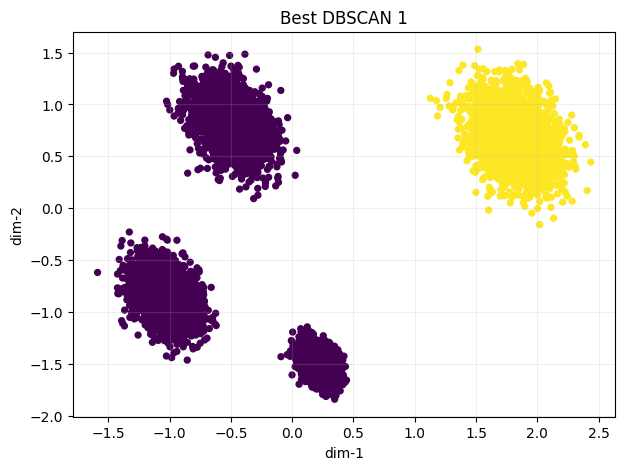

In [165]:
plot_2d_embedding(X_1_scaler, best_dbscan_1["labels"], "Best DBSCAN 1")

### **Итог:**

По silhouette самый лучший результат на 2 кластерах, но на графике видно, что на 2 кластерах происходит очень большой скачек silhouette, т.е. это выброс и если не учитывать 2, то максимальный silhouette на 5. По графику Inertia сгиб "локтя" находится тоже примерно где-то радом с 5, но при проецировании точек на плоскоть слишком явно отличимы 4 кластера, 4 и 5 довоно близкие числа, поэтому итоговое число класеров 4.

Для данного датасета оба метода являются хорошими, поскольку они дают довольно схожие результаты. Точки в этом датасете расположены довольно плотно, сложноть возникла с разными шкалами, необходимо использовать масштабирование.

**4 кластера**

# Датасет 2

### kmeans

In [49]:
k_means_results_2 = eval_kmeans_grid(X_2_scaler, kmeans_ks)

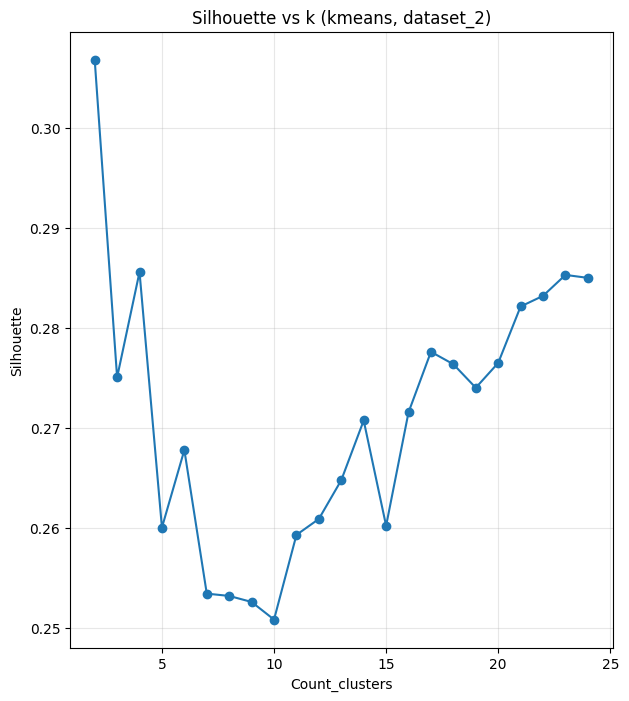

In [51]:
ks_2 = [r["params"]["k"] for r in k_means_results_2]
sil_2 = [r["metrics"]["silhouette"] for r in k_means_results_2]

plt.figure(figsize=(7, 8))
plt.plot(ks_2, sil_2, marker="o")
plt.title("Silhouette vs k (kmeans, dataset_2)")
plt.xlabel("Count_clusters")
plt.ylabel("Silhouette")
plt.grid(alpha=0.3)
plt.show()

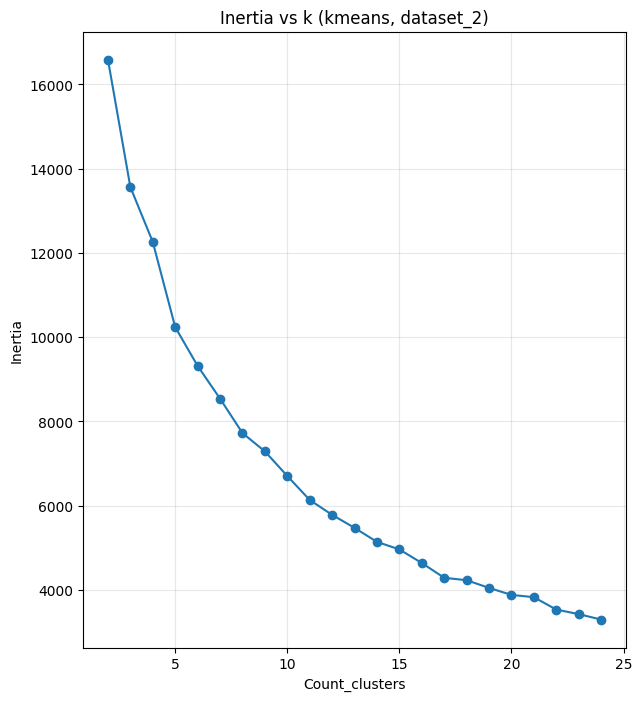

In [52]:
inertia_2 = [r["inertia"] for r in k_means_results_2]
plt.figure(figsize=(7,8))
plt.plot(ks_2, inertia_2, marker="o")
plt.title("Inertia vs k (kmeans, dataset_2)")
plt.xlabel("Count_clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

In [135]:
best_kmeans_2, best_kmeans_s_2 = pick_best_by_silhouette(k_means_results_2)
best_kmeans_2

{'algo': 'kmeans',
 'params': {'k': 2},
 'labels': array([0, 1, 1, ..., 1, 0, 0], shape=(8000,), dtype=int32),
 'metrics': {'silhouette': 0.3068610017701601,
  'davies_boundlin': None,
  'calinski_harabasz': 3573.3933329348392},
 'inertia': 16588.50103229558,
 'n_clasters': 2,
 'noise_frac': 0.0}

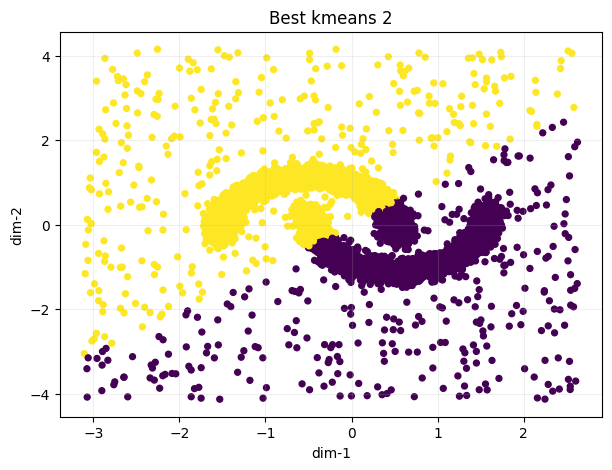

In [138]:
plot_2d_embedding(X_2_scaler, best_kmeans_2["labels"], "Best kmeans 2")

### DBSCAN

In [154]:
dbscan_results_2 = eval_dbscan_grid(X_2_scaler, eps, min_samples)

In [155]:
valid = [r for r in dbscan_results_2 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid))

valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid DBSCAN configs: 4
{'eps': 0.5, 'min_samples': 10} sil= 0.251 noise= 0.064 clusters= 2
{'eps': 0.5, 'min_samples': 8} sil= 0.242 noise= 0.062 clusters= 3
{'eps': 0.5, 'min_samples': 5} sil= -0.058 noise= 0.045 clusters= 14
{'eps': 0.5, 'min_samples': 3} sil= -0.063 noise= 0.025 clusters= 32


In [156]:
best_dbscan_2, best_dbscan_s_2 = pick_best_by_silhouette(dbscan_results_2)
best_dbscan_2

{'algo': 'dbscan',
 'params': {'eps': 0.5, 'min_samples': 10},
 'labels': array([-1, -1,  0, ...,  0,  0,  0], shape=(8000,)),
 'metrics': {'silhouette': 0.25120225459401474,
  'davies_boundlin': None,
  'calinski_harabasz': 26.168575636304777},
 'inertia': None,
 'n_clusters': 2,
 'noise_frac': 0.063625,
 'n_non_noise': 7491}

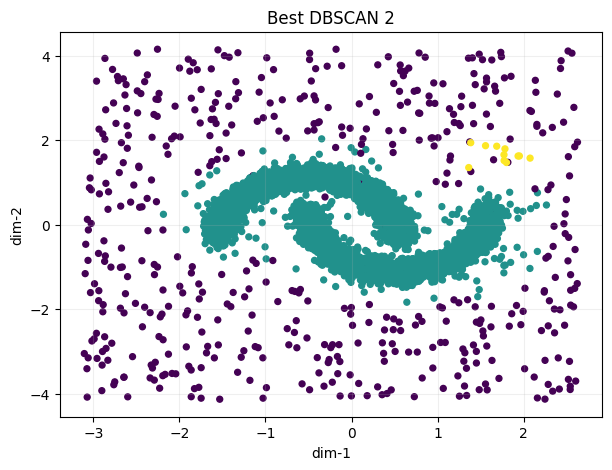

In [157]:
plot_2d_embedding(X_2_scaler, best_dbscan_2["labels"], "Best DBSCAN 2")

### **Итог:**

Лучшие метрики на silhouette и inertia на 2, это видно из графиков и из отображения точенк на 2d плоскость, явно видны 2 кластера. Best_kmeans и best_dbscan тоже при 2 кластерах. Лучшия является метод DBSCAN, хоть по лучшим метрикам они и дали одинаковые результаты, но на проекции на плоскость DBSCAN лучше разделил точки, kmeans пытался отнести все точки к какому либо кластеру в отличие от DBSKAN-на. В данном датасете много шумовых точек разбросанных по всей плоскости.

**2 кластера**

# Датасет 3

### kmeans

In [53]:
k_means_results_3 = eval_kmeans_grid(X_3_scaler, kmeans_ks)

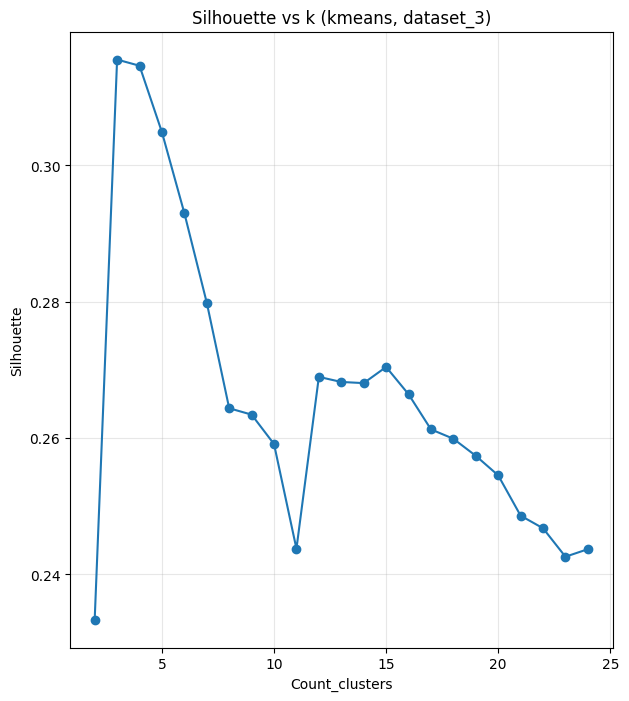

In [63]:
ks_3 = [r["params"]["k"] for r in k_means_results_3]
sil_3 = [r["metrics"]["silhouette"] for r in k_means_results_3]

plt.figure(figsize=(7, 8))
plt.plot(ks_3, sil_3, marker="o")
plt.title("Silhouette vs k (kmeans, dataset_3)")
plt.xlabel("Count_clusters")
plt.ylabel("Silhouette")
plt.grid(alpha=0.3)
plt.show()

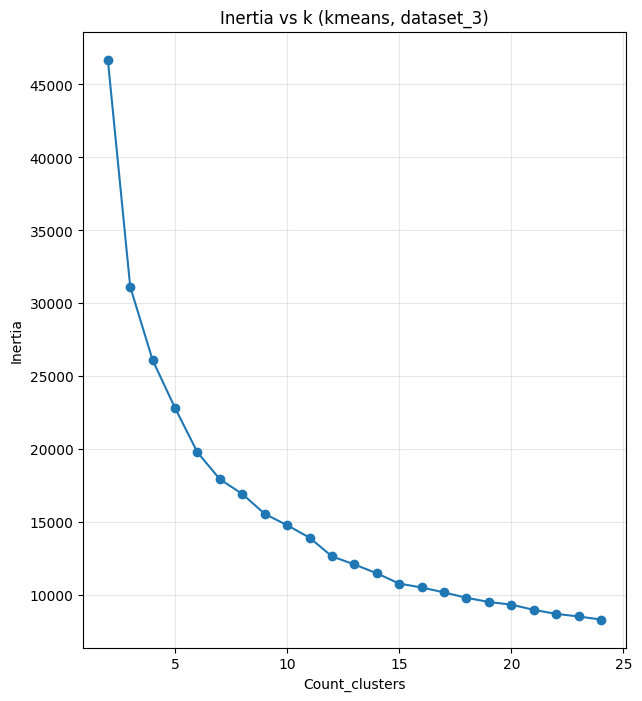

In [64]:
inertia_3 = [r["inertia"] for r in k_means_results_3]

plt.figure(figsize=(7,8))
plt.plot(ks_3, inertia_3, marker="o")
plt.title("Inertia vs k (kmeans, dataset_3)")
plt.xlabel("Count_clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

In [139]:
best_kmeans_3, best_kmeans_s_3 = pick_best_by_silhouette(k_means_results_3)
best_kmeans_3

{'algo': 'kmeans',
 'params': {'k': 3},
 'labels': array([2, 1, 1, ..., 1, 1, 1], shape=(15000,), dtype=int32),
 'metrics': {'silhouette': 0.31553248183109267,
  'davies_boundlin': None,
  'calinski_harabasz': 6957.158106946778},
 'inertia': 31123.497444205772,
 'n_clasters': 3,
 'noise_frac': 0.0}

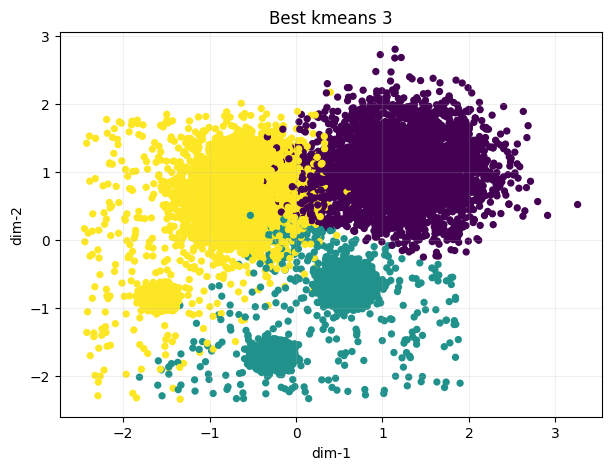

In [141]:
plot_2d_embedding(X_3_scaler, best_kmeans_3["labels"], "Best kmeans 3")

### DBSCAN

In [158]:
dbscan_results_3 = eval_dbscan_grid(X_3_scaler, eps, min_samples)

In [159]:
valid = [r for r in dbscan_results_3 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid))

valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid DBSCAN configs: 5
{'eps': 0.5, 'min_samples': 15} sil= 0.144 noise= 0.04 clusters= 2
{'eps': 0.5, 'min_samples': 10} sil= 0.142 noise= 0.032 clusters= 2
{'eps': 0.5, 'min_samples': 8} sil= 0.142 noise= 0.029 clusters= 2
{'eps': 0.5, 'min_samples': 5} sil= -0.104 noise= 0.022 clusters= 4
{'eps': 0.5, 'min_samples': 3} sil= -0.232 noise= 0.016 clusters= 12


In [160]:
best_dbscan_3, best_dbscan_s_3 = pick_best_by_silhouette(dbscan_results_3)
best_dbscan_3

{'algo': 'dbscan',
 'params': {'eps': 0.5, 'min_samples': 15},
 'labels': array([ 0, -1, -1, ...,  1,  1,  1], shape=(15000,)),
 'metrics': {'silhouette': 0.14371559638512676,
  'davies_boundlin': None,
  'calinski_harabasz': 1642.9394939943343},
 'inertia': None,
 'n_clusters': 2,
 'noise_frac': 0.03986666666666667,
 'n_non_noise': 14402}

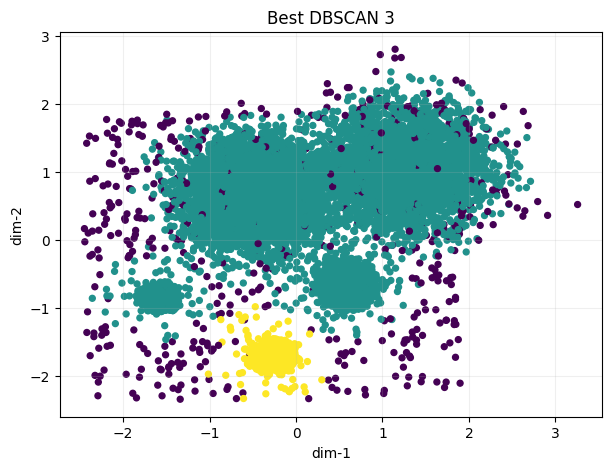

In [161]:
plot_2d_embedding(X_3_scaler, best_dbscan_3["labels"], "Best DBSCAN 3")

### **Итог:**

По 1 графику видно что лучший silhouette примерно на 3. 2 график показывает зависимсть inertia от k, сгиб "локтя" находится тоже примерно на 3-4. Лучший kmeans на 3, а лучший dbscan на 2. Исходя из графиков и метрик можно сделать вывод, что кластеров 3. Лучшим является kmeans, т.к. он более явно разделил кластеры и метрики у него выше (silhouette). Проблема в данном датасете в том, что кластеры находятся довольно близко друг к другу и трудно четко их отделить.

**3 кластера**

# Датасет 4

### kmeans

In [59]:
k_means_results_4 = eval_kmeans_grid(X_4_scaler, kmeans_ks)

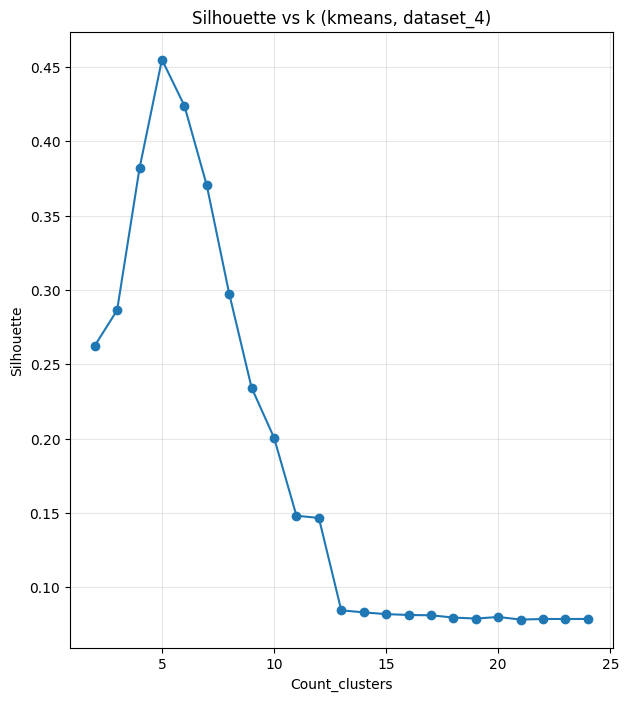

In [66]:
ks_4 = [r["params"]["k"] for r in k_means_results_4]
sil_4 = [r["metrics"]["silhouette"] for r in k_means_results_4]

plt.figure(figsize=(7, 8))
plt.plot(ks_4, sil_4, marker="o")
plt.title("Silhouette vs k (kmeans, dataset_4)")
plt.xlabel("Count_clusters")
plt.ylabel("Silhouette")
plt.grid(alpha=0.3)
plt.show()

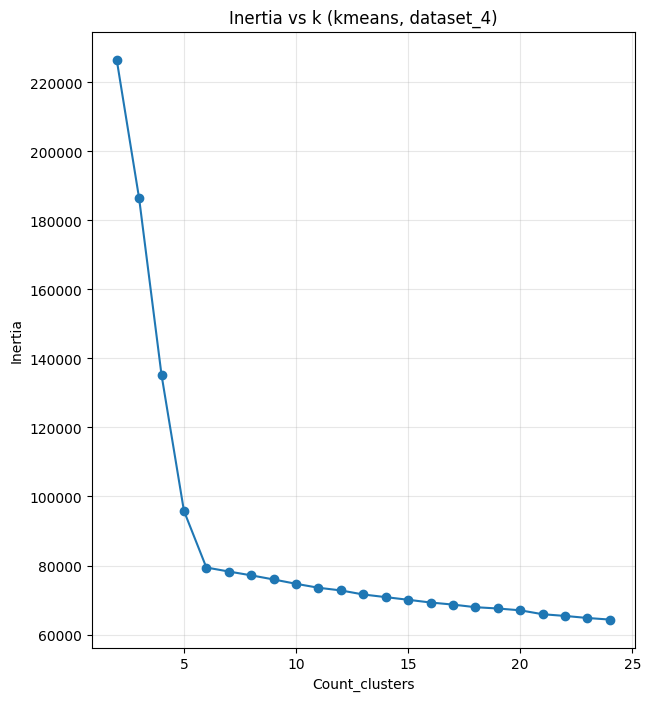

In [67]:
inertia_4 = [r["inertia"] for r in k_means_results_4]

plt.figure(figsize=(7,8))
plt.plot(ks_4, inertia_4, marker="o")
plt.title("Inertia vs k (kmeans, dataset_4)")
plt.xlabel("Count_clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

### DBSCAN

In [90]:
dbscan_results_4 = eval_dbscan_grid(X_4_scaler, eps, min_samples)

In [92]:
valid = [r for r in dbscan_results_4 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid))

valid_sorted = sorted(valid, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid DBSCAN configs: 37
{'eps': 1.5, 'min_samples': 15} sil= 0.615 noise= 0.859 clusters= 4
{'eps': 1.5, 'min_samples': 10} sil= 0.555 noise= 0.818 clusters= 5
{'eps': 2.0, 'min_samples': 15} sil= 0.483 noise= 0.323 clusters= 6
{'eps': 3.0, 'min_samples': 15} sil= 0.455 noise= 0.002 clusters= 5
{'eps': 3.0, 'min_samples': 10} sil= 0.455 noise= 0.002 clusters= 5
{'eps': 3.0, 'min_samples': 8} sil= 0.455 noise= 0.002 clusters= 5
{'eps': 3.0, 'min_samples': 3} sil= 0.455 noise= 0.002 clusters= 5
{'eps': 3.0, 'min_samples': 5} sil= 0.455 noise= 0.002 clusters= 5
{'eps': 3.5, 'min_samples': 3} sil= 0.455 noise= 0.0 clusters= 5
{'eps': 3.5, 'min_samples': 5} sil= 0.455 noise= 0.0 clusters= 5
{'eps': 3.5, 'min_samples': 10} sil= 0.455 noise= 0.0 clusters= 5
{'eps': 3.5, 'min_samples': 8} sil= 0.455 noise= 0.0 clusters= 5
{'eps': 3.5, 'min_samples': 15} sil= 0.455 noise= 0.0 clusters= 5
{'eps': 1.5, 'min_samples': 8} sil= 0.454 noise= 0.788 clusters= 9
{'eps': 2.5, 'min_samples': 15} sil= 0.4

In [147]:
best_kmeans_4, best_kmeans_s_4 = pick_best_by_silhouette(k_means_results_4)
best_kmeans_4

{'algo': 'kmeans',
 'params': {'k': 5},
 'labels': array([0, 1, 2, ..., 3, 4, 4], shape=(10000,), dtype=int32),
 'metrics': {'silhouette': 0.4548642894346598,
  'davies_boundlin': None,
  'calinski_harabasz': 5323.500116564786},
 'inertia': 95832.39973528287,
 'n_clasters': 5,
 'noise_frac': 0.0}

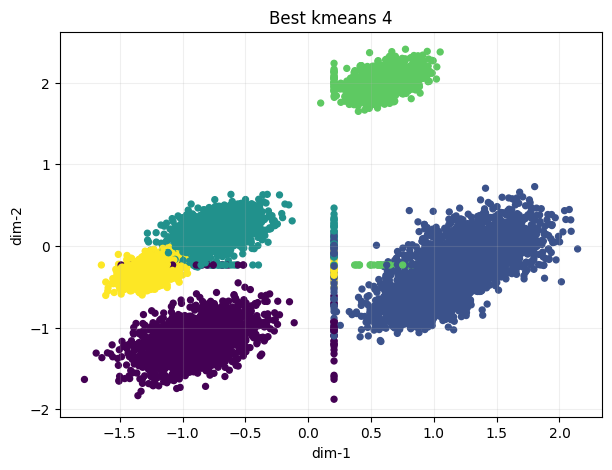

In [148]:
plot_2d_embedding(X_4_scaler, best_kmeans_4["labels"], "Best kmeans 4")

In [151]:
best_dbscan_4, best_dbscan_s_4 = pick_best_by_silhouette(dbscan_results_4)
best_dbscan_4

{'algo': 'dbscan',
 'params': {'eps': 1.5, 'min_samples': 15},
 'labels': array([-1, -1, -1, ...,  1, -1,  0], shape=(10000,)),
 'metrics': {'silhouette': 0.614708465228328,
  'davies_boundlin': None,
  'calinski_harabasz': 2829.4657566712854},
 'inertia': None,
 'n_clusters': 4,
 'noise_frac': 0.8586,
 'n_non_noise': 1414}

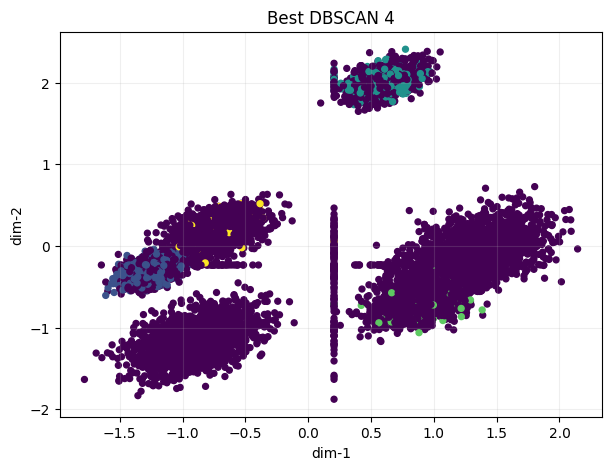

In [152]:
plot_2d_embedding(X_4_scaler, best_dbscan_4["labels"], "Best DBSCAN 4")

### **Итог:**

По 1 графику видно что лучший silhouette на 5. 2 график показывает зависимсть inertia от k, сгиб "локтя" находится тоже примерно на 5 или 6. Лучший kmeans на 5, а лучший dbscan на 5. Исходя из графиков и метрик можно сделать вывод, что кластеров 5. Проблема в данном датасете была из-за пропусков и категориальных данных. Лучшим является метод DBSCAN, на нем метрики выше (silhouette).

**5 кластеров**

АНАЛИЗ УСТОЙЧИВОСТИ K-MEANS (DATASET 2)
Количество кластеров: k = 3
Количество запусков: 10

INERTIA (чем ниже, тем лучше):
  Среднее: 13570.27
  Стандартное отклонение: 27.19
  Коэффициент вариации: 0.20%

SILHOUETTE (чем выше, тем лучше):
  Среднее: 0.273
  Стандартное отклонение: 0.0026


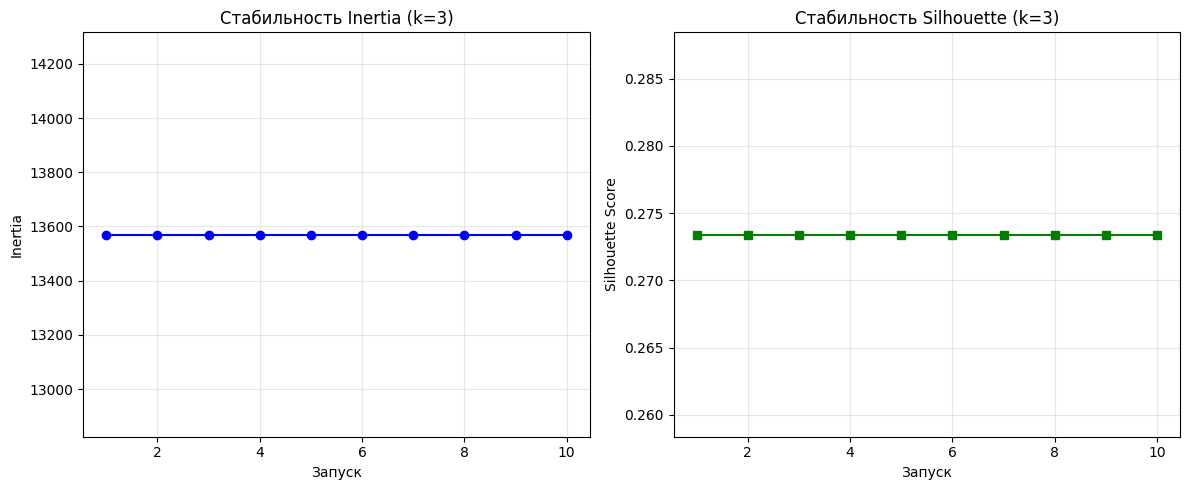

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ УСТОЙЧИВОСТИ:
Отличная устойчивость: Inertia стабильна между запусками
Отличная устойчивость: Silhouette стабилен между запусками


In [163]:
def evaluate_kmeans_stability(X, k, n_runs=10, random_state=RANDOM_STATE):
    """Оценка устойчивости K-Means для заданного k"""
    inertia_values = []
    silhouette_values = []
    
    for i in range(n_runs):
    
        current_random_state = random_state + i if random_state is not None else None
        
        try:
            model = KMeans(n_clusters=k, random_state=current_random_state, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=current_random_state, n_init=10)
            
        labels = model.fit_predict(X)
        
        inertia_values.append(float(model.inertia_))
        
        unique_labels = np.unique(labels)
        if len(unique_labels) > 1:
            sil = silhouette_score(X, labels)
            silhouette_values.append(sil)
        else:
            silhouette_values.append(0)
    
    inertia_mean = np.mean(inertia_values)
    inertia_std = np.std(inertia_values)
    inertia_cv = (inertia_std / inertia_mean) * 100 if inertia_mean > 0 else 100
    
    sil_mean = np.mean(silhouette_values)
    sil_std = np.std(silhouette_values)
    
    return {
        "k": k,
        "inertia_mean": inertia_mean,
        "inertia_std": inertia_std,
        "inertia_cv_percent": inertia_cv,
        "silhouette_mean": sil_mean,
        "silhouette_std": sil_std,
        "n_runs": n_runs
    }

optimal_k_2 = 3
stability_results_2 = evaluate_kmeans_stability(X_2_scaler, optimal_k_2, n_runs=10)

print("АНАЛИЗ УСТОЙЧИВОСТИ K-MEANS (DATASET 2)")
print(f"Количество кластеров: k = {optimal_k_2}")
print(f"Количество запусков: {stability_results_2['n_runs']}")
print("\nINERTIA (чем ниже, тем лучше):")
print(f"  Среднее: {stability_results_2['inertia_mean']:.2f}")
print(f"  Стандартное отклонение: {stability_results_2['inertia_std']:.2f}")
print(f"  Коэффициент вариации: {stability_results_2['inertia_cv_percent']:.2f}%")
print("\nSILHOUETTE (чем выше, тем лучше):")
print(f"  Среднее: {stability_results_2['silhouette_mean']:.3f}")
print(f"  Стандартное отклонение: {stability_results_2['silhouette_std']:.4f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


runs = range(1, 11)
inertia_runs = [evaluate_kmeans_stability(X_2_scaler, optimal_k_2, n_runs=10)['inertia_mean'] 
                for _ in range(10)] 

ax1.plot(runs, inertia_runs, marker='o', linestyle='-', color='blue')
ax1.set_xlabel('Запуск')
ax1.set_ylabel('Inertia')
ax1.set_title(f'Стабильность Inertia (k={optimal_k_2})')
ax1.grid(True, alpha=0.3)


silhouette_runs = [evaluate_kmeans_stability(X_2_scaler, optimal_k_2, n_runs=10)['silhouette_mean'] 
                   for _ in range(10)]  
ax2.plot(runs, silhouette_runs, marker='s', linestyle='-', color='green')
ax2.set_xlabel('Запуск')
ax2.set_ylabel('Silhouette Score')
ax2.set_title(f'Стабильность Silhouette (k={optimal_k_2})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ УСТОЙЧИВОСТИ:")

if stability_results_2['inertia_cv_percent'] < 5:
    print("Отличная устойчивость: Inertia стабильна между запусками")
elif stability_results_2['inertia_cv_percent'] < 10:
    print("Хорошая устойчивость: незначительные вариации Inertia")
elif stability_results_2['inertia_cv_percent'] < 20:
    print("Умеренная устойчивость: заметные вариации Inertia")
else:
    print("Низкая устойчивость: значительные вариации между запусками")

if stability_results_2['silhouette_std'] < 0.05:
    print("Отличная устойчивость: Silhouette стабилен между запусками")
elif stability_results_2['silhouette_std'] < 0.1:
    print("Хорошая устойчивость: незначительные вариации Silhouette")
elif stability_results_2['silhouette_std'] < 0.2:
    print("Умеренная устойчивость: заметные вариации Silhouette")
else:
    print("Низкая устойчивость: значительные вариации Silhouette")